In [2]:
# Imports and setup for image loading
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
H5_PATH = "Galaxy10_DECals(1).h5"
IMG_SIZE = 128  
BATCH_SIZE = 32 
NUM_CLASSES = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Load Data
with h5py.File(H5_PATH, "r") as f:
    images = np.array(f["images"])
    labels = np.array(f["ans"])



In [3]:
# AUGMENTATIONS - applying random rotations, horizontal flips, and vertical flips of the images
train_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(180), # Full rotation range
    T.ColorJitter(brightness=0.1, contrast=0.1), # Account for sensor noise
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Resizing and Normalizing the images to run efficiently
val_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Creating a class to grab image data easily
class GalaxyDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Split indices
n = len(images)
indices = np.arange(n)
np.random.shuffle(indices)

train_idx = indices[:int(0.8 * n)]
val_idx = indices[int(0.8 * n):]

train_ds = GalaxyDataset(images[train_idx], labels[train_idx], transform=train_transforms)
val_ds = GalaxyDataset(images[val_idx], labels[val_idx], transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

# MODEL SETUP
# Using EfficientNet-B0 
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
)
model = model.to(DEVICE)

# Calculate class weights for imbalance
class_counts = np.bincount(labels)
weights = 1. / torch.tensor(class_counts, dtype=torch.float)
weights = weights / weights.sum() * NUM_CLASSES
criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE), label_smoothing=0.1)

# TRAINING LOGIC - defining a function to run the epochs (with training and validation) and output loss and accuracy of the epoch
def run_epoch(loader, is_train, optimizer=None):
    model.train() if is_train else model.eval()
    losses, all_preds, all_labels = [], [], []
    
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE).long()
        
        with torch.set_grad_enabled(is_train):
            out = model(x)
            loss = criterion(out, y)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        
        losses.append(loss.item())
        all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        
    return np.mean(losses), accuracy_score(all_labels, all_preds)

# Freezing first, allow the model to keep its ability to see circles and edges
optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-3)
print("Starting Phase 1: Warming up Classifier...")
for epoch in range(3):
    loss, acc = run_epoch(train_loader, True, optimizer)
    val_loss, val_acc = run_epoch(val_loader, False)
    print(f"Epoch {epoch+1} | Train Acc: {acc:.3f} | Val Acc: {val_acc:.3f}")

# Full Fine-tuning, open the model to changing everything and learn from the images
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=2)

# Begin running the fine tuning
print("\nStarting Phase 2: Full Fine-tuning...")
for epoch in range(10):
    loss, acc = run_epoch(train_loader, True, optimizer)
    val_loss, val_acc = run_epoch(val_loader, False)
    scheduler.step(val_acc)
    print(f"Epoch {epoch+1} | Train Acc: {acc:.3f} | Val Acc: {val_acc:.3f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

Starting Phase 1: Warming up Classifier...


Epoch 1 | Train Acc: 0.279 | Val Acc: 0.320


Epoch 2 | Train Acc: 0.314 | Val Acc: 0.321


Epoch 3 | Train Acc: 0.314 | Val Acc: 0.364

Starting Phase 2: Full Fine-tuning...


Epoch 1 | Train Acc: 0.443 | Val Acc: 0.555 | LR: 0.000100


...

Epoch 6 | Train Acc: 0.741 | Val Acc: 0.778 | LR: 0.000100


Epoch 7 | Train Acc: 0.756 | Val Acc: 0.769 | LR: 0.000100


Epoch 8 | Train Acc: 0.764 | Val Acc: 0.792 | LR: 0.000100


Epoch 9 | Train Acc: 0.773 | Val Acc: 0.798 | LR: 0.000100


Epoch 10 | Train Acc: 0.781 | Val Acc: 0.806 | LR: 0.000100


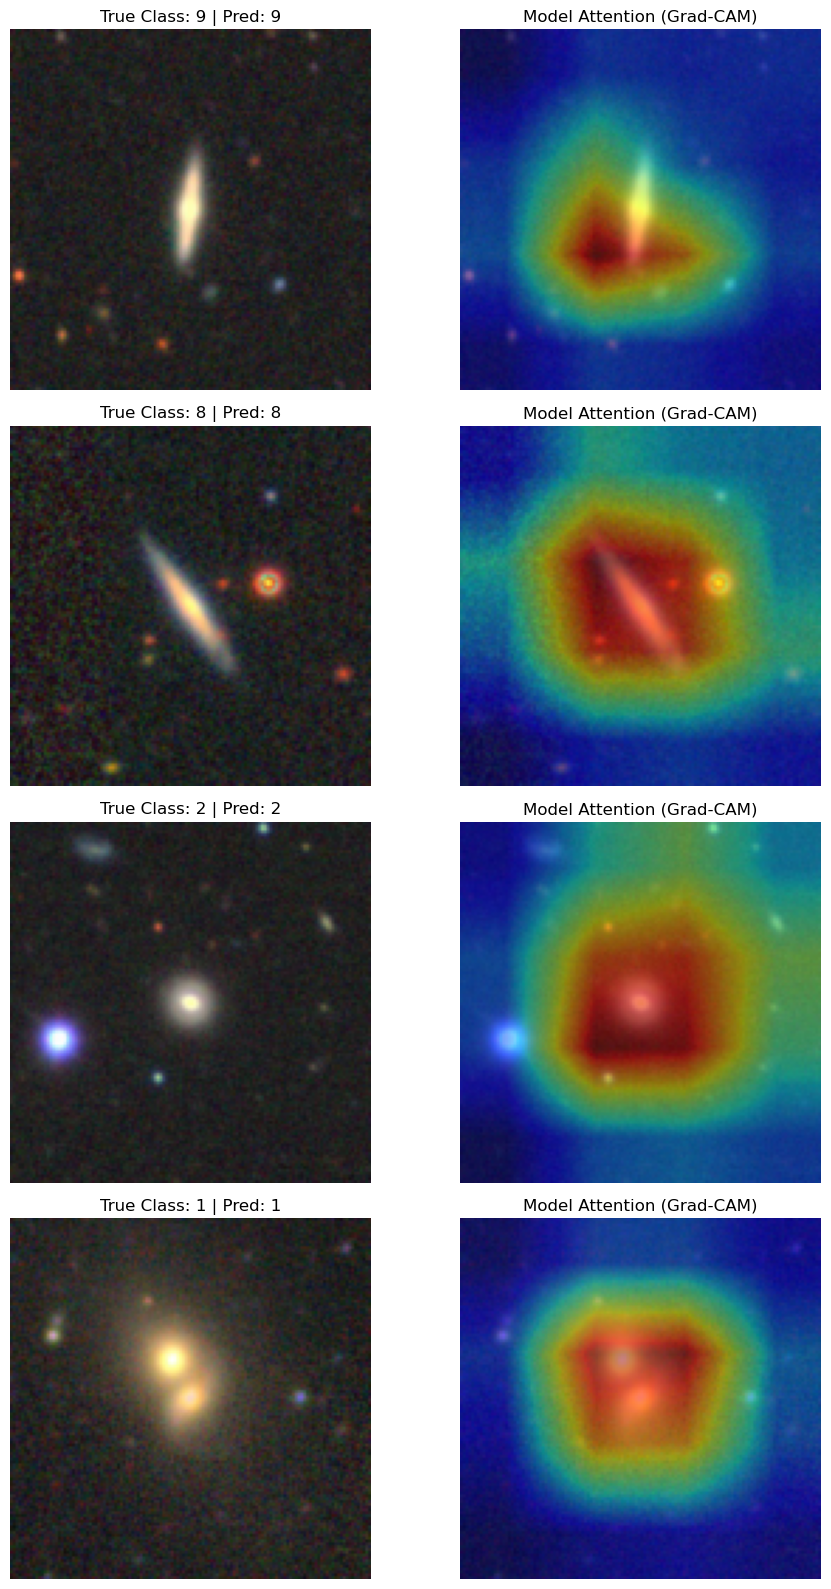

In [5]:
# Grad-Cam Visualization
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2 

# Identify the target layer (last conv layer of EfficientNet-B0)
target_layer = model.features[-1]

# Select a few samples from the Validation set
model.eval()
num_samples = 4
fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 4))

for i in range(num_samples):
    img, label = val_ds[i + 20] 
    
    heatmap, pred_idx = get_gradcam(model, img, target_layer)
    
    # De-normalize image for display
    img_display = img.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = img_display * std + mean
    img_display = np.clip(img_display, 0, 1)

    # Plot Original
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f"True Class: {label} | Pred: {pred_idx}")
    axes[i, 0].axis('off')

    # Plot Heatmap Overlay
    axes[i, 1].imshow(img_display)
    axes[i, 1].imshow(heatmap, cmap='jet', alpha=0.5) 
    axes[i, 1].set_title("Model Attention (Grad-CAM)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

Predicting for CM: 100%|██████████| 111/111 [00:09<00:00, 11.77it/s]


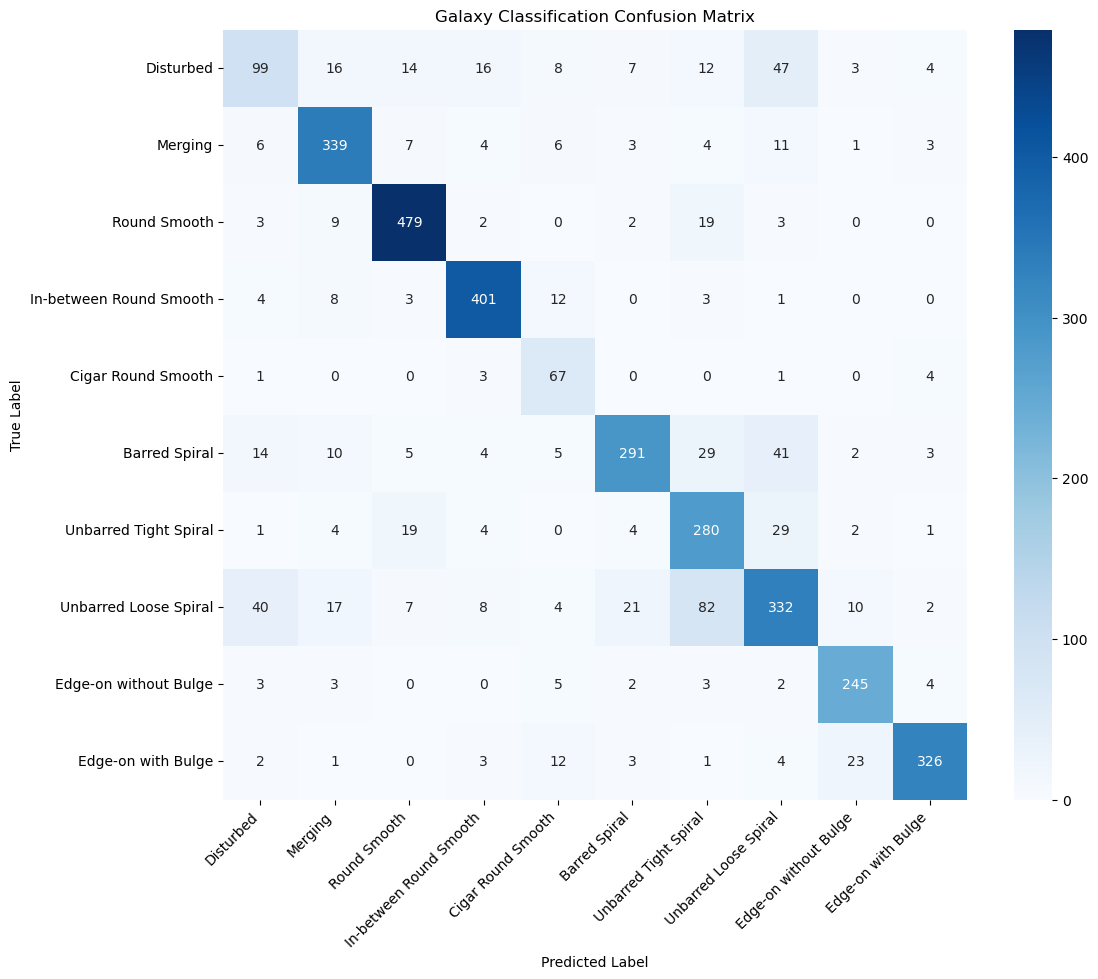

In [7]:
# Confusion Matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Define the class names for Galaxy10 DECals
class_names = ['Disturbed', 
               'Merging', 
               'Round Smooth', 
               'In-between Round Smooth', 
               'Cigar Round Smooth', 
               'Barred Spiral', 
               'Unbarred Tight Spiral', 
               'Unbarred Loose Spiral', 
               'Edge-on without Bulge', 
               'Edge-on with Bulge'
              ]

def plot_confusion_matrix(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    # Gather predictions
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Predicting for CM"):
            x = x.to(DEVICE)
            out = model(x)
            preds = torch.argmax(out, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
    
    # Calculate matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plotting
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Galaxy Classification Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.show()

# Run it on validation set
plot_confusion_matrix(model, val_loader)